In [34]:
import pandas as pd
import numpy as np
import os
import brightway2 as bw

import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker

In [35]:
bw.projects.set_current('Prospective LCA v5')

In [36]:
methodsDict = {'acidification':                    ('EF v3.0 no LT', 'acidification no LT', 'accumulated exceedance (ae) no LT'),
            'photochemical ozone formation':    ('EF v3.0 no LT', 'photochemical ozone formation: human health no LT', 'tropospheric ozone concentration increase no LT'),
            'particulate matter':               ('EF v3.0 no LT', 'particulate matter formation no LT', 'impact on human health no LT'),
            'ozone depletion':                  ('EF v3.0 no LT', 'ozone depletion no LT', 'ozone depletion potential (ODP)  no LT'),
            'ecotoxicity freshwater':           ('EF v3.0 no LT', 'ecotoxicity: freshwater no LT', 'comparative toxic unit for ecosystems (CTUe)  no LT'),
            'ionising radiation':               ('EF v3.0 no LT', 'ionising radiation: human health no LT', 'human exposure efficiency relative to u235 no LT'), 
            }    

In [37]:
methodsDictSorted = {key : methodsDict[key] for key in sorted(methodsDict)}

In [38]:
units = []
for key, values in methodsDictSorted.items():
    method = bw.methods.get(values)
    units.append(method['unit'])
units

['mol H+-Eq',
 'CTUe',
 'kBq U235-Eq',
 'kg CFC-11-Eq',
 'disease incidence',
 'kg NMVOC-Eq']

In [39]:
for i in range(0, len(units)):
    units[i] = units[i].replace('Eq', 'eq')
units

['mol H+-eq',
 'CTUe',
 'kBq U235-eq',
 'kg CFC-11-eq',
 'disease incidence',
 'kg NMVOC-eq']

In [40]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [41]:
hydrogenResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Hydrogen')
hydrogenResults = {}
impactCategories = []
for fileName in os.listdir(hydrogenResultsPath):
    if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
        filePath = os.path.join(hydrogenResultsPath, fileName)
        impactCategory = fileName.replace('hydrogen ', '')
        impactCategory = impactCategory.replace(' results.xlsx', '')
        impactCategories.append(impactCategory)
        dfs = pd.read_excel(filePath, sheet_name = None)
        dfAll = []
        for df in dfs.items():
            database = df[0]
            df = df[1]
            numCols = len(df.columns) - 1
            repeatedActivity = np.repeat(df['Activity'], numCols)
            dfNew = pd.DataFrame({
                'Activity' : repeatedActivity,
                'Location' : np.tile(df.columns[1:], len(df)),
                'Impact' : df.iloc[:, 1:].values.flatten(),
                'Database' : database
            })
            dfAll.append(dfNew)
        totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
    hydrogenResults[impactCategory] = totalImpactCatDF

for dfName, df in hydrogenResults.items():
    filteredDF = df[df['Location'] == 'GLO']
    hydrogenResults[dfName] = filteredDF

In [42]:
ammoniaResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Ammonia')
ammoniaResults = {}
impactCategories = []
for fileName in os.listdir(ammoniaResultsPath):
    if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
        filePath = os.path.join(ammoniaResultsPath, fileName)
        impactCategory = fileName.replace('ammonia ', '')
        impactCategory = impactCategory.replace(' results.xlsx', '')
        impactCategories.append(impactCategory)
        dfs = pd.read_excel(filePath, sheet_name = None)
        dfAll = []
        for df in dfs.items():
            database = df[0]
            df = df[1]
            numCols = len(df.columns) - 1
            repeatedActivity = np.repeat(df['Activity'], numCols)
            dfNew = pd.DataFrame({
                'Activity' : repeatedActivity,
                'Location' : np.tile(df.columns[1:], len(df)),
                'Impact' : df.iloc[:, 1:].values.flatten(),
                'Database' : database
            })
            dfAll.append(dfNew)
        totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
    ammoniaResults[impactCategory] = totalImpactCatDF

for dfName, df in ammoniaResults.items():
    filteredDF = df[df['Location'] == 'GLO']
    ammoniaResults[dfName] = filteredDF

In [43]:
methanolResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Methanol')
methanolResults = {}
impactCategories = []
for fileName in os.listdir(methanolResultsPath):
    if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
        filePath = os.path.join(methanolResultsPath, fileName)
        impactCategory = fileName.replace('methanol ', '')
        impactCategory = impactCategory.replace(' results.xlsx', '')
        impactCategories.append(impactCategory)
        dfs = pd.read_excel(filePath, sheet_name = None)
        dfAll = []
        for df in dfs.items():
            database = df[0]
            df = df[1]
            numCols = len(df.columns) - 1
            repeatedActivity = np.repeat(df['Activity'], numCols)
            dfNew = pd.DataFrame({
                'Activity' : repeatedActivity,
                'Location' : np.tile(df.columns[1:], len(df)),
                'Impact' : df.iloc[:, 1:].values.flatten(),
                'Database' : database
            })
            dfAll.append(dfNew)
        totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
    methanolResults[impactCategory] = totalImpactCatDF

for dfName, df in methanolResults.items():
    filteredDF = df[df['Location'] == 'GLO']
    methanolResults[dfName] = filteredDF

In [44]:
# ethyleneResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Ethylene')
# ethyleneResults = {}
# impactCategories = []
# for fileName in os.listdir(ethyleneResultsPath):
#     if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
#         filePath = os.path.join(ethyleneResultsPath, fileName)
#         impactCategory = fileName.replace('ethylene ', '')
#         impactCategory = impactCategory.replace(' results.xlsx', '')
#         impactCategories.append(impactCategory)
#         dfs = pd.read_excel(filePath, sheet_name = None)
#         dfAll = []
#         for df in dfs.items():
#             database = df[0]
#             df = df[1]
#             numCols = len(df.columns) - 1
#             repeatedActivity = np.repeat(df['Activity'], numCols)
#             dfNew = pd.DataFrame({
#                 'Activity' : repeatedActivity,
#                 'Location' : np.tile(df.columns[1:], len(df)),
#                 'Impact' : df.iloc[:, 1:].values.flatten(),
#                 'Database' : database
#             })
#             dfAll.append(dfNew)
#         totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
#     ethyleneResults[impactCategory] = totalImpactCatDF

# for dfName, df in ethyleneResults.items():
#     filteredDF = df[df['Location'] == 'GLO']
#     ethyleneResults[dfName] = filteredDF

In [45]:
impactCategories.sort()
impactCategories = ['acidification', 'ecotoxicity freshwater', 'ionising radiation', 'ozone depletion', 'particulate matter', 'photochemical ozone formation']
impactCategories

['acidification',
 'ecotoxicity freshwater',
 'ionising radiation',
 'ozone depletion',
 'particulate matter',
 'photochemical ozone formation']

In [46]:
years = ['2020', '2030', '2040', '2050']
alphabets = ['a ', 'b ', 'c ', 'd ', 'e ', 'f ']

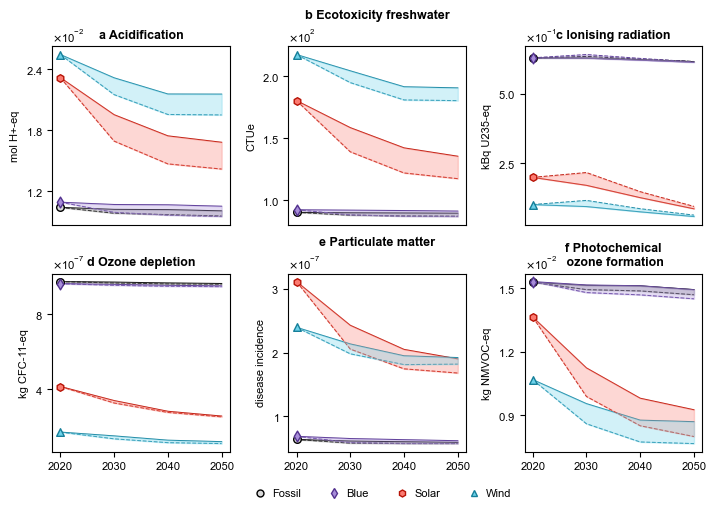

In [47]:
fig, ax = plt.subplots(2, 3, figsize = (fig_length[2], fig_height*0.5))

for i in range(0, len(impactCategories)):

    hydrogenResult = hydrogenResults[impactCategories[i]]
    hydrogenResultsRCP6 = hydrogenResult[hydrogenResult['Database'].str.contains('Base')]
    hydrogenBAURCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('solar')]

    hydrogenResultsRCP19 = hydrogenResult[hydrogenResult['Database'].str.contains('Base 2020') | hydrogenResult['Database'].str.contains('RCP19')]
    hydrogenBAURCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('solar')]

    hydrogenBAURCP6 = hydrogenBAURCP6.reset_index(drop=True)
    hydrogenBlueRCP6 = hydrogenBlueRCP6.reset_index(drop=True)
    hydrogenWindRCP6 = hydrogenWindRCP6.reset_index(drop = True)
    hydrogenSolarRCP6 = hydrogenSolarRCP6.reset_index(drop = True)

    hydrogenBAURCP19 = hydrogenBAURCP19.reset_index(drop=True)
    hydrogenBlueRCP19 = hydrogenBlueRCP19.reset_index(drop=True)
    hydrogenWindRCP19 = hydrogenWindRCP19.reset_index(drop = True)
    hydrogenSolarRCP19 = hydrogenSolarRCP19.reset_index(drop = True)

    ax[i // 3, i % 3].plot(years, hydrogenBAURCP6['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, hydrogenBlueRCP6['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, hydrogenSolarRCP6['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, hydrogenWindRCP6['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, hydrogenBAURCP19['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, hydrogenBlueRCP19['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, hydrogenSolarRCP19['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, hydrogenWindRCP19['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i // 3, i % 3].fill_between(years, hydrogenBAURCP6['Impact'], hydrogenBAURCP19['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i // 3, i % 3].fill_between(years, hydrogenBlueRCP6['Impact'], hydrogenBlueRCP19['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i // 3, i % 3].fill_between(years, hydrogenSolarRCP6['Impact'], hydrogenSolarRCP19['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i // 3, i % 3].fill_between(years, hydrogenWindRCP6['Impact'], hydrogenWindRCP19['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 3, i % 3].scatter(years[0], hydrogenBAURCP6['Impact'][0], label = 'Blue', s = 30, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], hydrogenBlueRCP6['Impact'][0], label = 'Blue', s = 30, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], hydrogenSolarRCP6['Impact'][0], label = 'Solar', s = 30, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], hydrogenWindRCP6['Impact'][0], label = 'Wind', s = 30, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    
    ax[i // 3, i % 3].set_title(alphabets[i] + impactCategories[i].capitalize(), fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
         ax[i // 3, i % 3].set_title(alphabets[i] + 'Photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'ecotoxicity freshwater':
    #     ax[i // 3, i % 3].set_title(alphabets[i] + 'ecotoxicity\n freshwater', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'particulate matter':
    #     ax[i // 3, i % 3].set_title(alphabets[i] + 'particulate\n matter', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'ionising radiation':
    #     ax[i // 3, i % 3].set_title(alphabets[i] + 'ionising\n radiation', fontweight = 'bold', fontsize = fontsize_title)

    ax[i // 3, i % 3].yaxis.set_major_locator(MaxNLocator(nbins = 3))
    ax[i // 3, i % 3].set_ylabel(units[i])
    ax[i // 3, i % 3].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i // 3, i % 3].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

for i in range(0, 2):
    for j in range(0, 3):
        if i < 1:
            ax[i, j].set_xticks([])

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Hydrogen absolute image SSP2 GLO main.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Hydrogen absolute image SSP2 GLO main.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

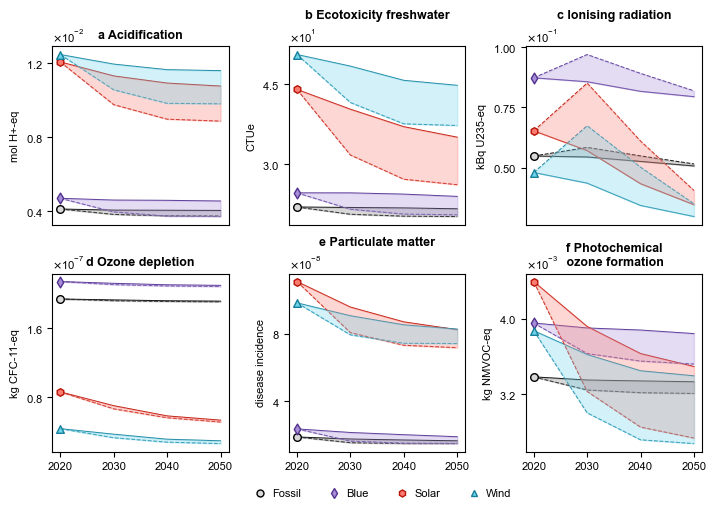

In [48]:
fig, ax = plt.subplots(2, 3, figsize = (fig_length[2], fig_height*0.5))

for i in range(0, len(impactCategories)):

    ammoniaResult = ammoniaResults[impactCategories[i]]
    ammoniaResultsRCP6 = ammoniaResult[ammoniaResult['Database'].str.contains('Base')]
    ammoniaBAURCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('solar')]

    ammoniaResultsRCP19 = ammoniaResult[ammoniaResult['Database'].str.contains('Base 2020') | ammoniaResult['Database'].str.contains('RCP19')]
    ammoniaBAURCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('solar')]

    ammoniaBAURCP6 = ammoniaBAURCP6.reset_index(drop=True)
    ammoniaBlueRCP6 = ammoniaBlueRCP6.reset_index(drop=True)
    ammoniaWindRCP6 = ammoniaWindRCP6.reset_index(drop = True)
    ammoniaSolarRCP6 = ammoniaSolarRCP6.reset_index(drop = True)

    ammoniaBAURCP19 = ammoniaBAURCP19.reset_index(drop=True)
    ammoniaBlueRCP19 = ammoniaBlueRCP19.reset_index(drop=True)
    ammoniaWindRCP19 = ammoniaWindRCP19.reset_index(drop = True)
    ammoniaSolarRCP19 = ammoniaSolarRCP19.reset_index(drop = True)

    ax[i // 3, i % 3].plot(years, ammoniaBAURCP6['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, ammoniaBlueRCP6['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, ammoniaSolarRCP6['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, ammoniaWindRCP6['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, ammoniaBAURCP19['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, ammoniaBlueRCP19['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, ammoniaSolarRCP19['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, ammoniaWindRCP19['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i // 3, i % 3].fill_between(years, ammoniaBAURCP6['Impact'], ammoniaBAURCP19['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i // 3, i % 3].fill_between(years, ammoniaBlueRCP6['Impact'], ammoniaBlueRCP19['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i // 3, i % 3].fill_between(years, ammoniaSolarRCP6['Impact'], ammoniaSolarRCP19['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i // 3, i % 3].fill_between(years, ammoniaWindRCP6['Impact'], ammoniaWindRCP19['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 3, i % 3].scatter(years[0], ammoniaBAURCP6['Impact'][0], label = 'Blue', s = 30, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], ammoniaBlueRCP6['Impact'][0], label = 'Blue', s = 30, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], ammoniaSolarRCP6['Impact'][0], label = 'Solar', s = 30, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], ammoniaWindRCP6['Impact'][0], label = 'Wind', s = 30, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 3, i % 3].set_title(alphabets[i] + impactCategories[i].capitalize(), fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
         ax[i // 3, i % 3].set_title(alphabets[i] + 'Photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'ecotoxicity freshwater':
    #     ax[i // 3, i % 3].set_title(alphabets[i] + 'ecotoxicity\n freshwater', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'particulate matter':
    #     ax[i // 3, i % 3].set_title(alphabets[i] + 'particulate\n matter', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'ionising radiation':
    #     ax[i // 3, i % 3].set_title(alphabets[i] + 'ionising\n radiation', fontweight = 'bold', fontsize = fontsize_title)
        
    ax[i // 3, i % 3].yaxis.set_major_locator(MaxNLocator(nbins = 3))
    ax[i // 3, i % 3].set_ylabel(units[i])
    ax[i // 3, i % 3].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i // 3, i % 3].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

for i in range(0, 2):
    for j in range(0, 3):
        if i < 1:
            ax[i, j].set_xticks([])

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ammonia absolute image SSP2 GLO main.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ammonia absolute image SSP2 GLO main.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

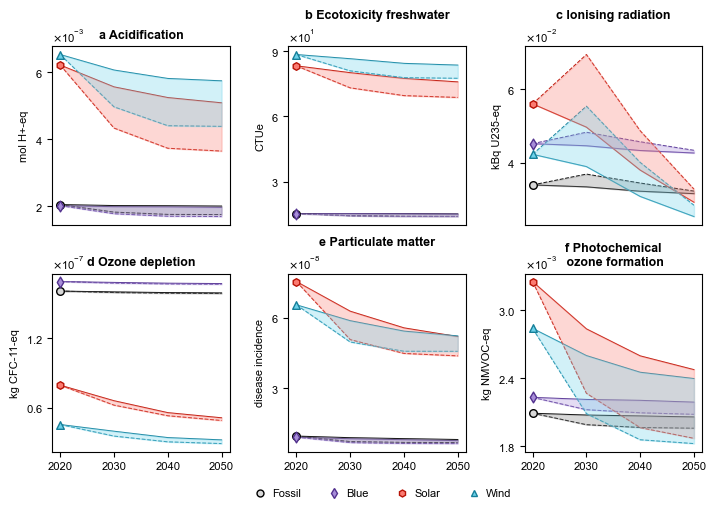

In [49]:
fig, ax = plt.subplots(2, 3, figsize = (fig_length[2], fig_height*0.5))

for i in range(0, len(impactCategories)):

    methanolResult = methanolResults[impactCategories[i]]
    methanolResultsRCP6 = methanolResult[methanolResult['Database'].str.contains('Base')]
    methanolBAURCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol, blue')]
    methanolWindRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    methanolResultsRCP19 = methanolResult[methanolResult['Database'].str.contains('Base 2020') | methanolResult['Database'].str.contains('RCP19')]
    methanolBAURCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol, blue')]
    methanolWindRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    methanolBAURCP6 = methanolBAURCP6.reset_index(drop=True)
    methanolBlueRCP6 = methanolBlueRCP6.reset_index(drop=True)
    methanolWindRCP6 = methanolWindRCP6.reset_index(drop = True)
    methanolSolarRCP6 = methanolSolarRCP6.reset_index(drop = True)

    methanolBAURCP19 = methanolBAURCP19.reset_index(drop=True)
    methanolBlueRCP19 = methanolBlueRCP19.reset_index(drop=True)
    methanolWindRCP19 = methanolWindRCP19.reset_index(drop = True)
    methanolSolarRCP19 = methanolSolarRCP19.reset_index(drop = True)

    ax[i // 3, i % 3].plot(years, methanolBAURCP6['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, methanolBlueRCP6['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, methanolSolarRCP6['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, methanolWindRCP6['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, methanolBAURCP19['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, methanolBlueRCP19['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, methanolSolarRCP19['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, methanolWindRCP19['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i // 3, i % 3].fill_between(years, methanolBAURCP6['Impact'], methanolBAURCP19['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i // 3, i % 3].fill_between(years, methanolBlueRCP6['Impact'], methanolBlueRCP19['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i // 3, i % 3].fill_between(years, methanolSolarRCP6['Impact'], methanolSolarRCP19['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i // 3, i % 3].fill_between(years, methanolWindRCP6['Impact'], methanolWindRCP19['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 3, i % 3].scatter(years[0], methanolBAURCP6['Impact'][0], label = 'Blue', s = 30, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], methanolBlueRCP6['Impact'][0], label = 'Blue', s = 30, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], methanolSolarRCP6['Impact'][0], label = 'Solar', s = 30, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], methanolWindRCP6['Impact'][0], label = 'Wind', s = 30, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 3, i % 3].set_title(alphabets[i] + impactCategories[i].capitalize(), fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
         ax[i // 3, i % 3].set_title(alphabets[i] + 'Photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'ecotoxicity freshwater':
    #     ax[i // 3, i % 3].set_title(alphabets[i] + 'Ecotoxicity\n freshwater', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'particulate matter':
    #     ax[i // 3, i % 3].set_title(alphabets[i] + 'Particulate\n matter', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'ionising radiation':
    #     ax[i // 3, i % 3].set_title(alphabets[i] + 'Ionising\n radiation', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'ozone depletion':
    #     ax[i // 3, i % 3].set_title(alphabets[i] + 'Ozone\n depletion', fontweight = 'bold', fontsize = fontsize_title)
        
    ax[i // 3, i % 3].yaxis.set_major_locator(MaxNLocator(nbins = 3))
    ax[i // 3, i % 3].set_ylabel(units[i])
    ax[i // 3, i % 3].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i // 3, i % 3].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

for i in range(0, 2):
    for j in range(0, 3):
        if i < 1:
            ax[i, j].set_xticks([])

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Methanol absolute image SSP2 GLO main.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Methanol absolute image SSP2 GLO main.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

In [50]:
"""fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    ethyleneResult = ethyleneResults[impactCategories[i]]
    ethyleneResultsRCP6 = ethyleneResult[ethyleneResult['Database'].str.contains('Base')]
    ethyleneBAURCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
    ethyleneBlueRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol, blue')]
    ethyleneWindRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    ethyleneSolarRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    ethyleneResultsRCP19 = ethyleneResult[ethyleneResult['Database'].str.contains('Base 2020') | ethyleneResult['Database'].str.contains('RCP19')]
    ethyleneBAURCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
    ethyleneBlueRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol, blue')]
    ethyleneWindRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    ethyleneSolarRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    ethyleneBAURCP6 = ethyleneBAURCP6.reset_index(drop=True)
    ethyleneBlueRCP6 = ethyleneBlueRCP6.reset_index(drop=True)
    ethyleneWindRCP6 = ethyleneWindRCP6.reset_index(drop = True)
    ethyleneSolarRCP6 = ethyleneSolarRCP6.reset_index(drop = True)

    ethyleneBAURCP19 = ethyleneBAURCP19.reset_index(drop=True)
    ethyleneBlueRCP19 = ethyleneBlueRCP19.reset_index(drop=True)
    ethyleneWindRCP19 = ethyleneWindRCP19.reset_index(drop = True)
    ethyleneSolarRCP19 = ethyleneSolarRCP19.reset_index(drop = True)

    ax[i // 3, i % 3].plot(years, ethyleneBAURCP6['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, ethyleneBlueRCP6['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, ethyleneSolarRCP6['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, ethyleneWindRCP6['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 3, i % 3].plot(years, ethyleneBAURCP19['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, ethyleneBlueRCP19['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, ethyleneSolarRCP19['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 3, i % 3].plot(years, ethyleneWindRCP19['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, ethyleneBAURCP6['Impact'], ethyleneBAURCP19['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, ethyleneBlueRCP6['Impact'], ethyleneBlueRCP19['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, ethyleneSolarRCP6['Impact'], ethyleneSolarRCP19['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, ethyleneWindRCP6['Impact'], ethyleneWindRCP19['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 3, i % 3].scatter(years[0], ethyleneBAURCP6['Impact'][0], label = 'Blue', s = 30, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], ethyleneBlueRCP6['Impact'][0], label = 'Blue', s = 30, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], ethyleneSolarRCP6['Impact'][0], label = 'Solar', s = 30, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 3, i % 3].scatter(years[0], ethyleneWindRCP6['Impact'][0], label = 'Wind', s = 30, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 3, i % 3].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 3, i % 3].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 3, i % 3].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 3, i % 3].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 3, i % 3].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

    ax[i // 3, i % 3].yaxis.set_major_locator(MaxNLocator(nbins = 3))
    ax[i // 3, i % 3].set_ylabel(units[i])
    ax[i // 3, i % 3].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i // 3, i % 3].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ethylene absolute image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ethylene absolute image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')"""

'fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))\n\nfor i in range(0, len(impactCategories)):\n\n    ethyleneResult = ethyleneResults[impactCategories[i]]\n    ethyleneResultsRCP6 = ethyleneResult[ethyleneResult[\'Database\'].str.contains(\'Base\')]\n    ethyleneBAURCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6[\'Activity\'].str.contains(\'ethylene, MTO; methanol, BAU\')]\n    ethyleneBlueRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6[\'Activity\'].str.contains(\'ethylene, MTO; methanol, blue\')]\n    ethyleneWindRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6[\'Activity\'].str.contains(\'ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity\')]\n    ethyleneSolarRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6[\'Activity\'].str.contains(\'ethylene

In [51]:
impactCategoriesMain = ['ozone depletion', 'particulate matter']
impactCategoriesMain

['ozone depletion', 'particulate matter']

/var/folders/62/bxlfmtm11fg29n96v31qbn9h0000gn/T/ipykernel_93479/4016990227.py:105: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0, 0].set_yticklabels(ytickLabels)
/var/folders/62/bxlfmtm11fg29n96v31qbn9h0000gn/T/ipykernel_93479/4016990227.py:112: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1, 0].set_yticklabels(ytickLabels)
/var/folders/62/bxlfmtm11fg29n96v31qbn9h0000gn/T/ipykernel_93479/4016990227.py:120: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1, 1].set_yticklabels(ytickLabels)


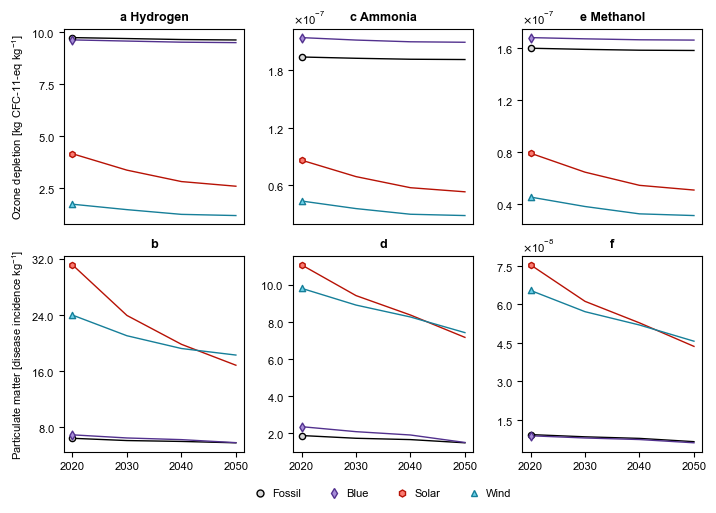

In [52]:
fig, ax = plt.subplots(2, 3, figsize = (fig_length[2], fig_height*0.5))

for i in range(0, len(impactCategoriesMain)):

    hydrogenResult = hydrogenResults[impactCategoriesMain[i]]
    hydrogenResultsRCP26 = hydrogenResult[hydrogenResult['Database'].str.contains('Base 2020') | hydrogenResult['Database'].str.contains('RCP26')]
    hydrogenBAURCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('solar')]
    hydrogenBAURCP26 = hydrogenBAURCP26.reset_index(drop=True)
    hydrogenBlueRCP26 = hydrogenBlueRCP26.reset_index(drop=True)
    hydrogenWindRCP26 = hydrogenWindRCP26.reset_index(drop = True)
    hydrogenSolarRCP26 = hydrogenSolarRCP26.reset_index(drop = True)

    ax[i, 0].plot(years, hydrogenBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-', linewidth = 1)
    ax[i, 0].plot(years, hydrogenBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-', linewidth = 1)
    ax[i, 0].plot(years, hydrogenSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-', linewidth = 1)
    ax[i, 0].plot(years, hydrogenWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-', linewidth = 1)
    ax[i, 0].scatter(years[0], hydrogenBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i, 0].scatter(years[0], hydrogenBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i, 0].scatter(years[0], hydrogenSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i, 0].scatter(years[0], hydrogenWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    
    ammoniaResult = ammoniaResults[impactCategoriesMain[i]]
    ammoniaResultsRCP26 = ammoniaResult[ammoniaResult['Database'].str.contains('Base 2020') | ammoniaResult['Database'].str.contains('RCP26')]
    ammoniaBAURCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('solar')]
    ammoniaBAURCP26 = ammoniaBAURCP26.reset_index(drop=True)
    ammoniaBlueRCP26 = ammoniaBlueRCP26.reset_index(drop=True)
    ammoniaWindRCP26 = ammoniaWindRCP26.reset_index(drop = True)
    ammoniaSolarRCP26 = ammoniaSolarRCP26.reset_index(drop = True)

    ax[i, 1].plot(years, ammoniaBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-', linewidth = 1)
    ax[i, 1].plot(years, ammoniaBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-', linewidth = 1)
    ax[i, 1].plot(years, ammoniaSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-', linewidth = 1)
    ax[i, 1].plot(years, ammoniaWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-', linewidth = 1)
    ax[i, 1].scatter(years[0], ammoniaBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i, 1].scatter(years[0], ammoniaBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i, 1].scatter(years[0], ammoniaSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i, 1].scatter(years[0], ammoniaWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    
    methanolResult = methanolResults[impactCategoriesMain[i]]
    methanolResultsRCP26 = methanolResult[methanolResult['Database'].str.contains('Base 2020') | methanolResult['Database'].str.contains('RCP26')]
    methanolBAURCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol, blue')]
    methanolWindRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolBAURCP26 = methanolBAURCP26.reset_index(drop=True)
    methanolBlueRCP26 = methanolBlueRCP26.reset_index(drop=True)
    methanolWindRCP26 = methanolWindRCP26.reset_index(drop = True)
    methanolSolarRCP26 = methanolSolarRCP26.reset_index(drop = True)
    
    ax[i, 2].plot(years, methanolBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-', linewidth = 1.0)
    ax[i, 2].plot(years, methanolBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-', linewidth = 1.0)
    ax[i, 2].plot(years, methanolSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-', linewidth = 1.0)
    ax[i, 2].plot(years, methanolWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-', linewidth = 1.0)
    ax[i, 2].scatter(years[0], methanolBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                            marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i, 2].scatter(years[0], methanolBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                            marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i, 2].scatter(years[0], methanolSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                            marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i, 2].scatter(years[0], methanolWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                            marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    if i == 0:
        ax[i, 0].set_ylabel('Ozone depletion [kg CFC-11-eq kg$^\mathdefault{-1}$]')
    if i == 1:
        ax[i, 0].set_ylabel('Particulate matter [disease incidence kg$^\mathdefault{-1}$]')    

    ax[0, 0].set_title('a Hydrogen', fontweight = 'bold', fontsize = fontsize_title)
    ax[0, 1].set_title('c Ammonia', fontweight = 'bold', fontsize = fontsize_title)
    ax[0, 2].set_title('e Methanol', fontweight = 'bold', fontsize = fontsize_title)
    ax[1, 0].set_title('b', fontweight = 'bold', fontsize = fontsize_title)
    ax[1, 1].set_title('d', fontweight = 'bold', fontsize = fontsize_title)
    ax[1, 2].set_title('f', fontweight = 'bold', fontsize = fontsize_title)

for i in range(0, 2):
    for j in range(0, 3):
        if i < 1:
            ax[i, j].set_xticks([])
        ax[i, j].yaxis.set_major_locator(MaxNLocator(4))
        ax[i, j].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
        ax[i, j].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

# ax[0, 0].yaxis.set_major_locator(MaxNLocator(5))
ax[1, 1].yaxis.set_major_locator(MaxNLocator(6))
ax[1, 2].yaxis.set_major_locator(MaxNLocator(6))

ytickLabels = ax[0, 0].get_yticklabels()
ytickLabels[1] = '$\\mathdefault{2.5}$'
ytickLabels[2] = '$\\mathdefault{5.0}$'
ytickLabels[3] = '$\\mathdefault{7.5}$'
ytickLabels[4] = '$\\mathdefault{10.0}$'
ax[0, 0].set_yticklabels(ytickLabels)

ytickLabels = ax[1, 0].get_yticklabels()
ytickLabels[1] = '$\\mathdefault{8.0}$'
ytickLabels[2] = '$\\mathdefault{16.0}$'
ytickLabels[3] = '$\\mathdefault{24.0}$'
ytickLabels[4] = '$\\mathdefault{32.0}$'
ax[1, 0].set_yticklabels(ytickLabels)

ytickLabels = ax[1, 1].get_yticklabels()
ytickLabels[1] = '$\\mathdefault{2.0}$'
ytickLabels[2] = '$\\mathdefault{4.0}$'
ytickLabels[3] = '$\\mathdefault{6.0}$'
ytickLabels[4] = '$\\mathdefault{8.0}$'
ytickLabels[5] = '$\\mathdefault{10.0}$'
ax[1, 1].set_yticklabels(ytickLabels)

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'All absolute image SSP2 GLO main.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'All absolute image SSP2 GLO main.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

In [53]:
impactCategoriesMain = ['particulate matter']
impactCategoriesMain

['particulate matter']

/var/folders/62/bxlfmtm11fg29n96v31qbn9h0000gn/T/ipykernel_93479/593667303.py:101: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_yticklabels(ytickLabels)
/var/folders/62/bxlfmtm11fg29n96v31qbn9h0000gn/T/ipykernel_93479/593667303.py:109: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_yticklabels(ytickLabels)


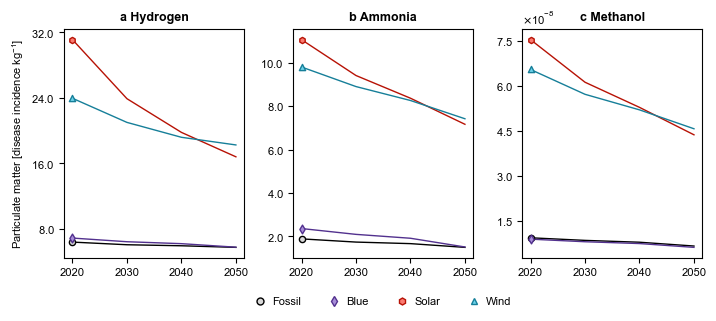

In [54]:
fig, ax = plt.subplots(1, 3, figsize = (fig_length[2], fig_height*0.3))

for i in range(0, len(impactCategoriesMain)):

    hydrogenResult = hydrogenResults[impactCategoriesMain[i]]
    hydrogenResultsRCP26 = hydrogenResult[hydrogenResult['Database'].str.contains('Base 2020') | hydrogenResult['Database'].str.contains('RCP26')]
    hydrogenBAURCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('solar')]
    hydrogenBAURCP26 = hydrogenBAURCP26.reset_index(drop=True)
    hydrogenBlueRCP26 = hydrogenBlueRCP26.reset_index(drop=True)
    hydrogenWindRCP26 = hydrogenWindRCP26.reset_index(drop = True)
    hydrogenSolarRCP26 = hydrogenSolarRCP26.reset_index(drop = True)

    ax[0].plot(years, hydrogenBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-', linewidth = 1)
    ax[0].plot(years, hydrogenBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-', linewidth = 1)
    ax[0].plot(years, hydrogenSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-', linewidth = 1)
    ax[0].plot(years, hydrogenWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-', linewidth = 1)
    ax[0].scatter(years[0], hydrogenBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[0].scatter(years[0], hydrogenBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[0].scatter(years[0], hydrogenSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[0].scatter(years[0], hydrogenWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    
    ammoniaResult = ammoniaResults[impactCategoriesMain[i]]
    ammoniaResultsRCP26 = ammoniaResult[ammoniaResult['Database'].str.contains('Base 2020') | ammoniaResult['Database'].str.contains('RCP26')]
    ammoniaBAURCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('solar')]
    ammoniaBAURCP26 = ammoniaBAURCP26.reset_index(drop=True)
    ammoniaBlueRCP26 = ammoniaBlueRCP26.reset_index(drop=True)
    ammoniaWindRCP26 = ammoniaWindRCP26.reset_index(drop = True)
    ammoniaSolarRCP26 = ammoniaSolarRCP26.reset_index(drop = True)

    ax[1].plot(years, ammoniaBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-', linewidth = 1)
    ax[1].plot(years, ammoniaBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-', linewidth = 1)
    ax[1].plot(years, ammoniaSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-', linewidth = 1)
    ax[1].plot(years, ammoniaWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-', linewidth = 1)
    ax[1].scatter(years[0], ammoniaBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[1].scatter(years[0], ammoniaBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[1].scatter(years[0], ammoniaSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[1].scatter(years[0], ammoniaWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    
    methanolResult = methanolResults[impactCategoriesMain[i]]
    methanolResultsRCP26 = methanolResult[methanolResult['Database'].str.contains('Base 2020') | methanolResult['Database'].str.contains('RCP26')]
    methanolBAURCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol, blue')]
    methanolWindRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolBAURCP26 = methanolBAURCP26.reset_index(drop=True)
    methanolBlueRCP26 = methanolBlueRCP26.reset_index(drop=True)
    methanolWindRCP26 = methanolWindRCP26.reset_index(drop = True)
    methanolSolarRCP26 = methanolSolarRCP26.reset_index(drop = True)
    
    ax[2].plot(years, methanolBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-', linewidth = 1.0)
    ax[2].plot(years, methanolBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-', linewidth = 1.0)
    ax[2].plot(years, methanolSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-', linewidth = 1.0)
    ax[2].plot(years, methanolWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-', linewidth = 1.0)
    ax[2].scatter(years[0], methanolBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                            marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[2].scatter(years[0], methanolBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                            marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[2].scatter(years[0], methanolSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                            marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[2].scatter(years[0], methanolWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                            marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    
    ax[0].set_ylabel('Particulate matter [disease incidence kg$^\mathdefault{-1}$]')    
    ax[0].set_title('a Hydrogen', fontweight = 'bold', fontsize = fontsize_title)
    ax[1].set_title('b Ammonia', fontweight = 'bold', fontsize = fontsize_title)
    ax[2].set_title('c Methanol', fontweight = 'bold', fontsize = fontsize_title)
    # ax[1, 0].set_title('b', fontweight = 'bold', fontsize = fontsize_title)
    # ax[1, 1].set_title('d', fontweight = 'bold', fontsize = fontsize_title)
    # ax[1, 2].set_title('f', fontweight = 'bold', fontsize = fontsize_title)

for i in range(0, 3):
    # if i < 0:
    #     ax[i, j].set_xticks([])
    ax[i].yaxis.set_major_locator(MaxNLocator(4))
    ax[i].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

# ax[0, 0].yaxis.set_major_locator(MaxNLocator(5))
ax[1].yaxis.set_major_locator(MaxNLocator(6))
ax[2].yaxis.set_major_locator(MaxNLocator(6))

ytickLabels = ax[0].get_yticklabels()
ytickLabels[1] = '$\\mathdefault{8.0}$'
ytickLabels[2] = '$\\mathdefault{16.0}$'
ytickLabels[3] = '$\\mathdefault{24.0}$'
ytickLabels[4] = '$\\mathdefault{32.0}$'
ax[0].set_yticklabels(ytickLabels)

ytickLabels = ax[1].get_yticklabels()
ytickLabels[1] = '$\\mathdefault{2.0}$'
ytickLabels[2] = '$\\mathdefault{4.0}$'
ytickLabels[3] = '$\\mathdefault{6.0}$'
ytickLabels[4] = '$\\mathdefault{8.0}$'
ytickLabels[5] = '$\\mathdefault{10.0}$'
ax[1].set_yticklabels(ytickLabels)

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Particulate absolute image SSP2 GLO main.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Particulate absolute image SSP2 GLO main.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

In [55]:
impactCategoriesMain = ['ozone depletion', 'particulate matter']
impactCategoriesMain

['ozone depletion', 'particulate matter']

/var/folders/62/bxlfmtm11fg29n96v31qbn9h0000gn/T/ipykernel_93479/1193028713.py:255: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0, 0].set_yticklabels(ytickLabels)
/var/folders/62/bxlfmtm11fg29n96v31qbn9h0000gn/T/ipykernel_93479/1193028713.py:262: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1, 0].set_yticklabels(ytickLabels)
/var/folders/62/bxlfmtm11fg29n96v31qbn9h0000gn/T/ipykernel_93479/1193028713.py:270: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1, 1].set_yticklabels(ytickLabels)


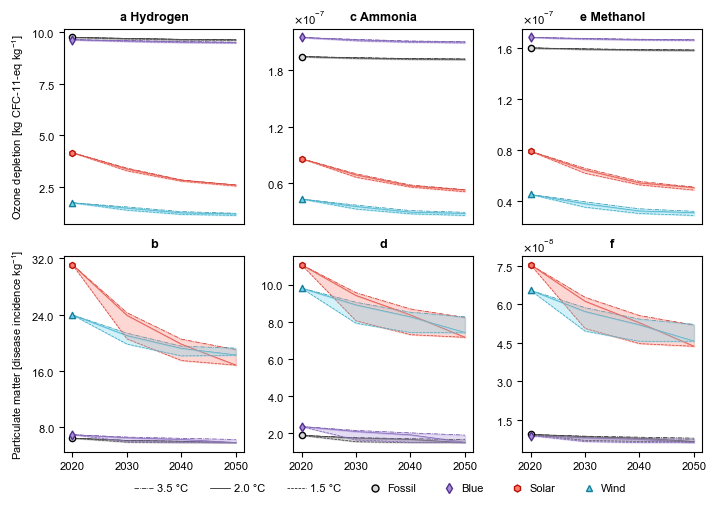

In [56]:
fig, ax = plt.subplots(2, 3, figsize = (fig_length[2], fig_height*0.5))

for i in range(0, len(impactCategoriesMain)):

    hydrogenResult = hydrogenResults[impactCategoriesMain[i]]
    hydrogenResultsRCP26 = hydrogenResult[hydrogenResult['Database'].str.contains('Base 2020') | hydrogenResult['Database'].str.contains('RCP26')]
    hydrogenBAURCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('solar')]
    hydrogenBAURCP26 = hydrogenBAURCP26.reset_index(drop=True)
    hydrogenBlueRCP26 = hydrogenBlueRCP26.reset_index(drop=True)
    hydrogenWindRCP26 = hydrogenWindRCP26.reset_index(drop = True)
    hydrogenSolarRCP26 = hydrogenSolarRCP26.reset_index(drop = True)

    hydrogenResultsRCP6 = hydrogenResult[hydrogenResult['Database'].str.contains('Base') | hydrogenResult['Database'].str.contains('RCP6')]
    hydrogenBAURCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('solar')]
    hydrogenBAURCP6 = hydrogenBAURCP26.reset_index(drop=True)
    hydrogenBlueRCP6 = hydrogenBlueRCP6.reset_index(drop=True)
    hydrogenWindRCP6 = hydrogenWindRCP6.reset_index(drop = True)
    hydrogenSolarRCP6 = hydrogenSolarRCP6.reset_index(drop = True)

    hydrogenResultsRCP19 = hydrogenResult[hydrogenResult['Database'].str.contains('Base 2020') | hydrogenResult['Database'].str.contains('RCP19')]
    hydrogenBAURCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('solar')]
    hydrogenBAURCP19 = hydrogenBAURCP19.reset_index(drop=True)
    hydrogenBlueRCP19 = hydrogenBlueRCP19.reset_index(drop=True)
    hydrogenWindRCP19 = hydrogenWindRCP19.reset_index(drop = True)
    hydrogenSolarRCP19 = hydrogenSolarRCP19.reset_index(drop = True)

    ax[i, 0].plot(years, hydrogenBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-', linewidth = 0.5)
    ax[i, 0].plot(years, hydrogenBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-', linewidth = 0.5)
    ax[i, 0].plot(years, hydrogenSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-', linewidth = 0.5)
    ax[i, 0].plot(years, hydrogenWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-', linewidth = 0.5)

    ax[i, 0].plot(years, hydrogenBAURCP6['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-.', linewidth = 0.5)
    ax[i, 0].plot(years, hydrogenBlueRCP6['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-.', linewidth = 0.5)
    ax[i, 0].plot(years, hydrogenSolarRCP6['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-.', linewidth = 0.5)
    ax[i, 0].plot(years, hydrogenWindRCP6['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-.', linewidth = 0.5)

    ax[i, 0].plot(years, hydrogenBAURCP19['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '--', linewidth = 0.5)
    ax[i, 0].plot(years, hydrogenBlueRCP19['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '--', linewidth = 0.5)
    ax[i, 0].plot(years, hydrogenSolarRCP19['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '--', linewidth = 0.5)
    ax[i, 0].plot(years, hydrogenWindRCP19['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '--', linewidth = 0.5)

    ax[i, 0].scatter(years[0], hydrogenBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i, 0].scatter(years[0], hydrogenBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i, 0].scatter(years[0], hydrogenSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i, 0].scatter(years[0], hydrogenWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    
    ax[i, 0].fill_between(years, hydrogenBAURCP6['Impact'], hydrogenBAURCP26['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i, 0].fill_between(years, hydrogenBlueRCP6['Impact'], hydrogenBlueRCP26['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i, 0].fill_between(years, hydrogenSolarRCP6['Impact'], hydrogenSolarRCP26['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i, 0].fill_between(years, hydrogenWindRCP6['Impact'], hydrogenWindRCP26['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i, 0].fill_between(years, hydrogenBAURCP26['Impact'], hydrogenBAURCP19['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i, 0].fill_between(years, hydrogenBlueRCP26['Impact'], hydrogenBlueRCP19['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i, 0].fill_between(years, hydrogenSolarRCP26['Impact'], hydrogenSolarRCP19['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i, 0].fill_between(years, hydrogenWindRCP26['Impact'], hydrogenWindRCP19['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ammoniaResult = ammoniaResults[impactCategoriesMain[i]]
    ammoniaResultsRCP26 = ammoniaResult[ammoniaResult['Database'].str.contains('Base 2020') | ammoniaResult['Database'].str.contains('RCP26')]
    ammoniaBAURCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('solar')]
    ammoniaBAURCP26 = ammoniaBAURCP26.reset_index(drop=True)
    ammoniaBlueRCP26 = ammoniaBlueRCP26.reset_index(drop=True)
    ammoniaWindRCP26 = ammoniaWindRCP26.reset_index(drop = True)
    ammoniaSolarRCP26 = ammoniaSolarRCP26.reset_index(drop = True)

    ammoniaResultsRCP6 = ammoniaResult[ammoniaResult['Database'].str.contains('Base') | ammoniaResult['Database'].str.contains('RCP6')]
    ammoniaBAURCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('solar')]
    ammoniaBAURCP6 = ammoniaBAURCP6.reset_index(drop=True)
    ammoniaBlueRCP6 = ammoniaBlueRCP6.reset_index(drop=True)
    ammoniaWindRCP6 = ammoniaWindRCP6.reset_index(drop = True)
    ammoniaSolarRCP6 = ammoniaSolarRCP6.reset_index(drop = True)

    ammoniaResultsRCP19 = ammoniaResult[ammoniaResult['Database'].str.contains('Base 2020') | ammoniaResult['Database'].str.contains('RCP19')]
    ammoniaBAURCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('solar')]
    ammoniaBAURCP19 = ammoniaBAURCP19.reset_index(drop=True)
    ammoniaBlueRCP19 = ammoniaBlueRCP19.reset_index(drop=True)
    ammoniaWindRCP19 = ammoniaWindRCP19.reset_index(drop = True)
    ammoniaSolarRCP19 = ammoniaSolarRCP19.reset_index(drop = True)

    ax[i, 1].plot(years, ammoniaBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-', linewidth = 0.5)
    ax[i, 1].plot(years, ammoniaBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-', linewidth = 0.5)
    ax[i, 1].plot(years, ammoniaSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-', linewidth = 0.5)
    ax[i, 1].plot(years, ammoniaWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-', linewidth = 0.5)

    ax[i, 1].plot(years, ammoniaBAURCP6['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-.', linewidth = 0.5)
    ax[i, 1].plot(years, ammoniaBlueRCP6['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-.', linewidth = 0.5)
    ax[i, 1].plot(years, ammoniaSolarRCP6['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-.', linewidth = 0.5)
    ax[i, 1].plot(years, ammoniaWindRCP6['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-.', linewidth = 0.5)

    ax[i, 1].plot(years, ammoniaBAURCP19['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '--', linewidth = 0.5)
    ax[i, 1].plot(years, ammoniaBlueRCP19['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '--', linewidth = 0.5)
    ax[i, 1].plot(years, ammoniaSolarRCP19['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '--', linewidth = 0.5)
    ax[i, 1].plot(years, ammoniaWindRCP19['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '--', linewidth = 0.5)

    ax[i, 1].scatter(years[0], ammoniaBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i, 1].scatter(years[0], ammoniaBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i, 1].scatter(years[0], ammoniaSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i, 1].scatter(years[0], ammoniaWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    
    ax[i, 1].fill_between(years, ammoniaBAURCP6['Impact'], ammoniaBAURCP26['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i, 1].fill_between(years, ammoniaBlueRCP6['Impact'], ammoniaBlueRCP26['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i, 1].fill_between(years, ammoniaSolarRCP6['Impact'], ammoniaSolarRCP26['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i, 1].fill_between(years, ammoniaWindRCP6['Impact'], ammoniaWindRCP26['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i, 1].fill_between(years, ammoniaBAURCP26['Impact'], ammoniaBAURCP19['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i, 1].fill_between(years, ammoniaBlueRCP26['Impact'], ammoniaBlueRCP19['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i, 1].fill_between(years, ammoniaSolarRCP26['Impact'], ammoniaSolarRCP19['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i, 1].fill_between(years, ammoniaWindRCP26['Impact'], ammoniaWindRCP19['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    methanolResult = methanolResults[impactCategoriesMain[i]]
    methanolResultsRCP26 = methanolResult[methanolResult['Database'].str.contains('Base 2020') | methanolResult['Database'].str.contains('RCP26')]
    methanolBAURCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol, blue')]
    methanolWindRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolBAURCP26 = methanolBAURCP26.reset_index(drop=True)
    methanolBlueRCP26 = methanolBlueRCP26.reset_index(drop=True)
    methanolWindRCP26 = methanolWindRCP26.reset_index(drop = True)
    methanolSolarRCP26 = methanolSolarRCP26.reset_index(drop = True)

    methanolResultsRCP6 = methanolResult[methanolResult['Database'].str.contains('Base') | methanolResult['Database'].str.contains('RCP6')]
    methanolBAURCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol, blue')]
    methanolWindRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolBAURCP6 = methanolBAURCP6.reset_index(drop=True)
    methanolBlueRCP6 = methanolBlueRCP6.reset_index(drop=True)
    methanolWindRCP6 = methanolWindRCP6.reset_index(drop = True)
    methanolSolarRCP6 = methanolSolarRCP6.reset_index(drop = True)

    methanolResultsRCP19 = methanolResult[methanolResult['Database'].str.contains('Base 2020') | methanolResult['Database'].str.contains('RCP19')]
    methanolBAURCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol, blue')]
    methanolWindRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolBAURCP19 = methanolBAURCP19.reset_index(drop=True)
    methanolBlueRCP19 = methanolBlueRCP19.reset_index(drop=True)
    methanolWindRCP19 = methanolWindRCP19.reset_index(drop = True)
    methanolSolarRCP19 = methanolSolarRCP19.reset_index(drop = True)
    
    ax[i, 2].plot(years, methanolBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-', linewidth = 0.5)
    ax[i, 2].plot(years, methanolBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-', linewidth = 0.5)
    ax[i, 2].plot(years, methanolSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-', linewidth = 0.5)
    ax[i, 2].plot(years, methanolWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-', linewidth = 0.5)

    ax[i, 2].plot(years, methanolBAURCP6['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '-.', linewidth = 0.5)
    ax[i, 2].plot(years, methanolBlueRCP6['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '-.', linewidth = 0.5)
    ax[i, 2].plot(years, methanolSolarRCP6['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '-.', linewidth = 0.5)
    ax[i, 2].plot(years, methanolWindRCP6['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '-.', linewidth = 0.5)

    ax[i, 2].plot(years, methanolBAURCP19['Impact'], label = 'Fossil', color = 'black', zorder = 0, linestyle = '--', linewidth = 0.5)
    ax[i, 2].plot(years, methanolBlueRCP19['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linestyle = '--', linewidth = 0.5)
    ax[i, 2].plot(years, methanolSolarRCP19['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linestyle = '--', linewidth = 0.5)
    ax[i, 2].plot(years, methanolWindRCP19['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linestyle = '--', linewidth = 0.5)

    ax[i, 2].scatter(years[0], methanolBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                            marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i, 2].scatter(years[0], methanolBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                            marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i, 2].scatter(years[0], methanolSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                            marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i, 2].scatter(years[0], methanolWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                            marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    
    ax[i, 2].fill_between(years, methanolBAURCP6['Impact'], methanolBAURCP26['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i, 2].fill_between(years, methanolBlueRCP6['Impact'], methanolBlueRCP26['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i, 2].fill_between(years, methanolSolarRCP6['Impact'], methanolSolarRCP26['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i, 2].fill_between(years, methanolWindRCP6['Impact'], methanolWindRCP26['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i, 2].fill_between(years, methanolBAURCP26['Impact'], methanolBAURCP19['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i, 2].fill_between(years, methanolBlueRCP26['Impact'], methanolBlueRCP19['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i, 2].fill_between(years, methanolSolarRCP26['Impact'], methanolSolarRCP19['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i, 2].fill_between(years, methanolWindRCP26['Impact'], methanolWindRCP19['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    if i == 0:
        ax[i, 0].set_ylabel('Ozone depletion [kg CFC-11-eq kg$^\mathdefault{-1}$]')
    if i == 1:
        ax[i, 0].set_ylabel('Particulate matter [disease incidence kg$^\mathdefault{-1}$]')    

    ax[0, 0].set_title('a Hydrogen', fontweight = 'bold', fontsize = fontsize_title)
    ax[0, 1].set_title('c Ammonia', fontweight = 'bold', fontsize = fontsize_title)
    ax[0, 2].set_title('e Methanol', fontweight = 'bold', fontsize = fontsize_title)
    ax[1, 0].set_title('b', fontweight = 'bold', fontsize = fontsize_title)
    ax[1, 1].set_title('d', fontweight = 'bold', fontsize = fontsize_title)
    ax[1, 2].set_title('f', fontweight = 'bold', fontsize = fontsize_title)

for i in range(0, 2):
    for j in range(0, 3):
        if i < 1:
            ax[i, j].set_xticks([])
        ax[i, j].yaxis.set_major_locator(MaxNLocator(4))
        ax[i, j].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
        ax[i, j].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

ax[1, 1].yaxis.set_major_locator(MaxNLocator(6))
ax[1, 2].yaxis.set_major_locator(MaxNLocator(6))

legend_elements =   [Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = '3.5 °C', linewidth = 0.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = '2.0 °C', linewidth = 0.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = '1.5 °C', linewidth = 0.5),
                    Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 5),
                    Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                    Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                    Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend = fig.legend(handles = legend_elements, frameon = False, loc = "upper center", ncol = 7, 
           prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

for i in range(len(legend.legend_handles)):
    if i < 3:
        handle = legend.legend_handles[i]
        handle.set_xdata([0, 4, 14])

ytickLabels = ax[0, 0].get_yticklabels()
ytickLabels[1] = '$\\mathdefault{2.5}$'
ytickLabels[2] = '$\\mathdefault{5.0}$'
ytickLabels[3] = '$\\mathdefault{7.5}$'
ytickLabels[4] = '$\\mathdefault{10.0}$'
ax[0, 0].set_yticklabels(ytickLabels)

ytickLabels = ax[1, 0].get_yticklabels()
ytickLabels[1] = '$\\mathdefault{8.0}$'
ytickLabels[2] = '$\\mathdefault{16.0}$'
ytickLabels[3] = '$\\mathdefault{24.0}$'
ytickLabels[4] = '$\\mathdefault{32.0}$'
ax[1, 0].set_yticklabels(ytickLabels)

ytickLabels = ax[1, 1].get_yticklabels()
ytickLabels[1] = '$\\mathdefault{2.0}$'
ytickLabels[2] = '$\\mathdefault{4.0}$'
ytickLabels[3] = '$\\mathdefault{6.0}$'
ytickLabels[4] = '$\\mathdefault{8.0}$'
ytickLabels[5] = '$\\mathdefault{10.0}$'
ax[1, 1].set_yticklabels(ytickLabels)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'All scenarios absolute image SSP2 GLO main.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'All scenarios absolute image SSP2 GLO main.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

In [57]:
methodsDict = {'acidification':                    ('EF v3.0 no LT', 'acidification no LT', 'accumulated exceedance (ae) no LT'),
               'eutrophication freshwater':        ('EF v3.0 no LT', 'eutrophication: freshwater no LT', 'fraction of nutrients reaching freshwater end compartment (P) no LT'),
               'eutrophication marine':            ('EF v3.0 no LT', 'eutrophication: marine no LT', 'fraction of nutrients reaching marine end compartment (N) no LT'),
               'eutrophication terrestrial':       ('EF v3.0 no LT', 'eutrophication: terrestrial no LT', 'accumulated exceedance (AE)  no LT'),
               'photochemical ozone formation':    ('EF v3.0 no LT', 'photochemical ozone formation: human health no LT', 'tropospheric ozone concentration increase no LT'),
               'ecotoxicity freshwater':           ('EF v3.0 no LT', 'ecotoxicity: freshwater no LT', 'comparative toxic unit for ecosystems (CTUe)  no LT'),
               'human toxicity carcinogenic':      ('EF v3.0 no LT', 'human toxicity: carcinogenic no LT', 'comparative toxic unit for human (CTUh)  no LT'),
               'human toxicity non-carcinogenic':  ('EF v3.0 no LT', 'human toxicity: non-carcinogenic no LT', 'comparative toxic unit for human (CTUh)  no LT'),
               'ionising radiation':               ('EF v3.0 no LT', 'ionising radiation: human health no LT', 'human exposure efficiency relative to u235 no LT'), 
               'resource use fossils':             ('EF v3.0 no LT', 'energy resources: non-renewable no LT', 'abiotic depletion potential (ADP): fossil fuels no LT'),
               'resource use mineral and metals':  ('EF v3.0 no LT', 'material resources: metals/minerals no LT', 'abiotic depletion potential (ADP): elements (ultimate reserves) no LT'),
               'water use':                        ('EF v3.0 no LT', 'water use no LT', 'user deprivation potential (deprivation-weighted water consumption) no LT')
            }    

In [58]:
impactCategories = ['acidification', 'ecotoxicity freshwater', 
                    'eutrophication marine', 'eutrophication terrestrial',
                    'photochemical ozone formation', 'eutrophication freshwater',
                    'human toxicity carcinogenic', 'human toxicity non-carcinogenic',
                    'ionising radiation', 'resource use fossils', 
                    'resource use mineral and metals', 'water use']
impactCategories.sort()
impactCategories

['acidification',
 'ecotoxicity freshwater',
 'eutrophication freshwater',
 'eutrophication marine',
 'eutrophication terrestrial',
 'human toxicity carcinogenic',
 'human toxicity non-carcinogenic',
 'ionising radiation',
 'photochemical ozone formation',
 'resource use fossils',
 'resource use mineral and metals',
 'water use']

In [59]:
methodsDictSorted = {key : methodsDict[key] for key in sorted(methodsDict)}

In [60]:
units = []
for key, values in methodsDictSorted.items():
    method = bw.methods.get(values)
    units.append(method['unit'])
units

['mol H+-Eq',
 'CTUe',
 'kg PO4-Eq',
 'kg N-Eq',
 'mol N-Eq',
 'CTUh',
 'CTUh',
 'kBq U235-Eq',
 'kg NMVOC-Eq',
 'MJ, net calorific value',
 'kg Sb-Eq',
 'm3 world eq. deprived']

In [61]:
for i in range(0, len(units)):
    units[i] = units[i].replace('Eq', 'eq')
units

['mol H+-eq',
 'CTUe',
 'kg PO4-eq',
 'kg N-eq',
 'mol N-eq',
 'CTUh',
 'CTUh',
 'kBq U235-eq',
 'kg NMVOC-eq',
 'MJ, net calorific value',
 'kg Sb-eq',
 'm3 world eq. deprived']

In [62]:
units = ['mol H$^\mathdefault{+}$-eq', 'CTUe', 'kg PO$_\mathdefault{4}$-eq', 
         'kg N-eq', 'mol N-eq', 'CTUh', 
         'CTUh', 'kBq U-235-eq', 'kg NMVOC-eq',
         'MJ, net calorific value', 'kg Sb-eq', 'm$^\mathdefault{3}$ world eq. deprived']
for i in range(0, len(units)):
    units[i] = '[' + units[i] + ' kg$^\mathdefault{-1}$]'

In [63]:
years = ['2020', '2030', '2040', '2050']
alphabets = ['a ', 'b ', 'c ', 'd ', 'e ', 'f ', 'g ', 'h ', 'i ', 'j ', 'k ', 'l ']

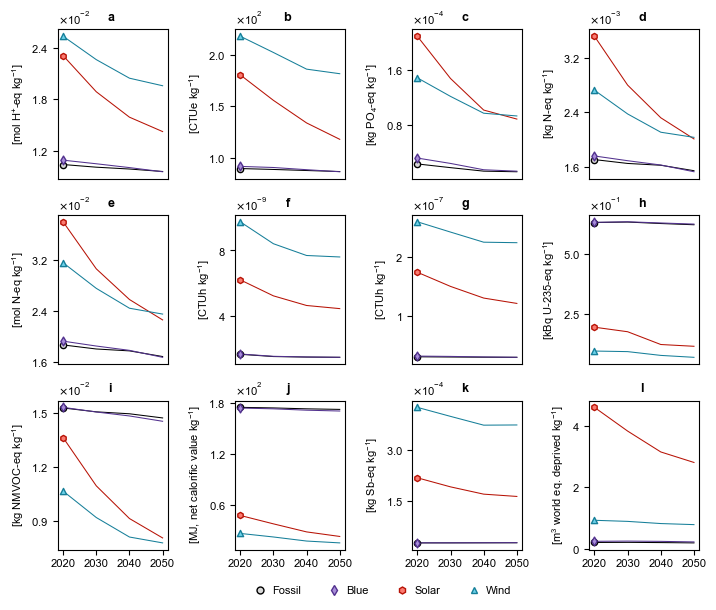

In [64]:
fig, ax = plt.subplots(3, 4, figsize = (fig_length[2], fig_height*0.6))

for i in range(0, len(impactCategories)):

    hydrogenResult = hydrogenResults[impactCategories[i]]
    hydrogenResultsRCP26 = hydrogenResult[hydrogenResult['Database'].str.contains('Base 2020') | hydrogenResult['Database'].str.contains('RCP26')]
    hydrogenBAURCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP26 = hydrogenResultsRCP26[hydrogenResultsRCP26['Activity'].str.contains('solar')]

    hydrogenBAURCP26 = hydrogenBAURCP26.reset_index(drop=True)
    hydrogenBlueRCP26 = hydrogenBlueRCP26.reset_index(drop=True)
    hydrogenWindRCP26 = hydrogenWindRCP26.reset_index(drop = True)
    hydrogenSolarRCP26 = hydrogenSolarRCP26.reset_index(drop = True)

    ax[i // 4, i % 4].plot(years, hydrogenBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75, linestyle = '-')
    ax[i // 4, i % 4].plot(years, hydrogenBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '-')
    ax[i // 4, i % 4].plot(years, hydrogenSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '-')
    ax[i // 4, i % 4].plot(years, hydrogenWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '-')

    ax[i // 4, i % 4].scatter(years[0], hydrogenBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], hydrogenBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], hydrogenSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], hydrogenWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i], fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'ecotoxicity freshwater':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'ecotoxicity\n freshwater', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'eutrophication freshwater':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'eutrophication\n freshwater', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'eutrophication marine':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'eutrophication\n marine', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'eutrophication terrestrial':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'eutrophication\n terrestrial', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'resource use fossils':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n fossils', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'human toxicity carcinogenic':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'human toxicity non-carcinogenic':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'photochemical ozone formation':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'resource use mineral and metals':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

    ax[i // 4, i % 4].yaxis.set_major_locator(MaxNLocator(nbins = 3))
    ax[i // 4, i % 4].set_ylabel(units[i])
    ax[i // 4, i % 4].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i // 4, i % 4].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

for i in range(0, 4):
    for j in range(0, 4):
        if i < 2:
            ax[i, j].set_xticks([])

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Hydrogen all absolute image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Hydrogen all absolute image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

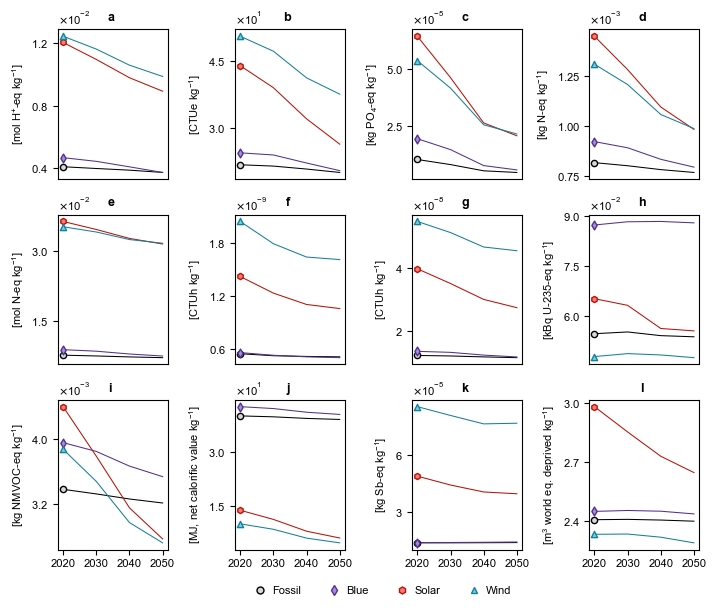

In [65]:
fig, ax = plt.subplots(3, 4, figsize = (fig_length[2], fig_height*0.6))

for i in range(0, len(impactCategories)):

    ammoniaResult = ammoniaResults[impactCategories[i]]
    ammoniaResultsRCP26 = ammoniaResult[ammoniaResult['Database'].str.contains('Base 2020') | ammoniaResult['Database'].str.contains('RCP26')]
    ammoniaBAURCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP26 = ammoniaResultsRCP26[ammoniaResultsRCP26['Activity'].str.contains('solar')]

    ammoniaBAURCP26 = ammoniaBAURCP26.reset_index(drop=True)
    ammoniaBlueRCP26 = ammoniaBlueRCP26.reset_index(drop=True)
    ammoniaWindRCP26 = ammoniaWindRCP26.reset_index(drop = True)
    ammoniaSolarRCP26 = ammoniaSolarRCP26.reset_index(drop = True)

    ax[i // 4, i % 4].plot(years, ammoniaBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, ammoniaBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, ammoniaSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, ammoniaWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    
    ax[i // 4, i % 4].scatter(years[0], ammoniaBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], ammoniaBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], ammoniaSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], ammoniaWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i], fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'ecotoxicity freshwater':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'ecotoxicity\n freshwater', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'eutrophication freshwater':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'eutrophication\n freshwater', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'eutrophication marine':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'eutrophication\n marine', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'eutrophication terrestrial':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'eutrophication\n terrestrial', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'resource use fossils':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n fossils', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'human toxicity carcinogenic':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'human toxicity non-carcinogenic':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'photochemical ozone formation':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'resource use mineral and metals':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

    ax[i // 4, i % 4].yaxis.set_major_locator(MaxNLocator(nbins = 3))
    ax[i // 4, i % 4].set_ylabel(units[i])
    ax[i // 4, i % 4].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i // 4, i % 4].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

for i in range(0, 4):
    for j in range(0, 4):
        if i < 2:
            ax[i, j].set_xticks([])

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ammonia all absolute image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ammonia all absolute image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

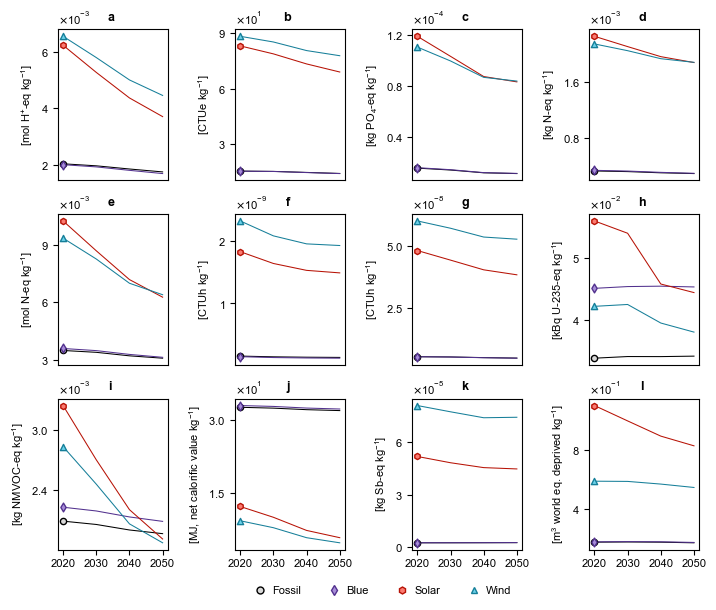

In [66]:
fig, ax = plt.subplots(3, 4, figsize = (fig_length[2], fig_height*0.6))

for i in range(0, len(impactCategories)):

    methanolResult = methanolResults[impactCategories[i]]
    methanolResultsRCP26 = methanolResult[methanolResult['Database'].str.contains('Base 2020') | methanolResult['Database'].str.contains('RCP26')]
    methanolBAURCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol, blue')]
    methanolWindRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP26 = methanolResultsRCP26[methanolResultsRCP26['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    methanolBAURCP26 = methanolBAURCP26.reset_index(drop=True)
    methanolBlueRCP26 = methanolBlueRCP26.reset_index(drop=True)
    methanolWindRCP26 = methanolWindRCP26.reset_index(drop = True)
    methanolSolarRCP26 = methanolSolarRCP26.reset_index(drop = True)

    ax[i // 4, i % 4].plot(years, methanolBAURCP26['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, methanolBlueRCP26['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, methanolSolarRCP26['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, methanolWindRCP26['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    
    ax[i // 4, i % 4].scatter(years[0], methanolBAURCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], methanolBlueRCP26['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], methanolSolarRCP26['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], methanolWindRCP26['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i], fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'ecotoxicity freshwater':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'ecotoxicity\n freshwater', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'eutrophication freshwater':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'eutrophication\n freshwater', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'eutrophication marine':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'eutrophication\n marine', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'eutrophication terrestrial':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'eutrophication\n terrestrial', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'resource use fossils':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n fossils', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'human toxicity carcinogenic':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'human toxicity non-carcinogenic':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'photochemical ozone formation':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    # if impactCategories[i] == 'resource use mineral and metals':
    #     ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

    ax[i // 4, i % 4].yaxis.set_major_locator(MaxNLocator(nbins = 3))
    ax[i // 4, i % 4].set_ylabel(units[i])
    ax[i // 4, i % 4].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i // 4, i % 4].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

for i in range(0, 4):
    for j in range(0, 4):
        if i < 2:
            ax[i, j].set_xticks([])

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Methanol all absolute image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Methanol all absolute image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')